# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Aftab Asghar
**Student ID:** 023-24-0234
**Section:** G
**GitHub:** https://github.com/aftab-soomro
**Kaggle:** https://www.kaggle.com/aftabgaming
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
import re
import string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [2]:
# Task 1 -- load spam.csv, inspect shape/head/class balance
# The UCI SMS Spam file ships as Windows-1252/Latin-1, not UTF-8, and carries
# 3 mostly-empty stray columns (parsing artifacts from stray commas inside a
# handful of messages) -- drop those and rename the two real columns.
spam_df = pd.read_csv("spam.csv", encoding="latin-1")
spam_df = spam_df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})

print("spam.csv shape:", spam_df.shape)
print("Each row is one SMS text message, labelled spam or ham (legitimate).")
display(spam_df.head())

print("\nClass balance:")
print(spam_df["label"].value_counts())
print((spam_df["label"].value_counts(normalize=True) * 100).round(2))


spam.csv shape: (5572, 2)
Each row is one SMS text message, labelled spam or ham (legitimate).


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Class balance:
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [3]:
# Task 1 (continued) -- load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_df = pd.read_csv("Tweets.csv")
print("Tweets.csv shape (all sentiments):", tweets_df.shape)
print("Each row is one tweet directed at a US airline, labelled by sentiment.")

print("\nClass balance (all 3 classes):")
print(tweets_df["airline_sentiment"].value_counts())
print((tweets_df["airline_sentiment"].value_counts(normalize=True) * 100).round(2))

# Keep only positive/negative -- drop neutral for this lab
tweets_df = tweets_df[tweets_df["airline_sentiment"] != "neutral"].reset_index(drop=True)
print("\nAfter dropping neutral rows:", tweets_df.shape)
print(tweets_df["airline_sentiment"].value_counts())
print((tweets_df["airline_sentiment"].value_counts(normalize=True) * 100).round(2))
display(tweets_df[["airline_sentiment", "text"]].head())


Tweets.csv shape (all sentiments): (14640, 15)
Each row is one tweet directed at a US airline, labelled by sentiment.

Class balance (all 3 classes):
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64

After dropping neutral rows: (11541, 15)
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


,airline_sentiment,text
0,positive,@VirginAmerica plus you've added commercials t...
1,negative,@VirginAmerica it's really aggressive to blast...
2,negative,@VirginAmerica and it's a really big bad thing...
3,negative,@VirginAmerica seriously would pay $30 a fligh...
4,positive,"@VirginAmerica yes, nearly every time I fly VX..."


**Answer 2 (Task A — spam):**
The practical problem is deciding, for every incoming SMS, whether it should reach the user's inbox or be filtered out as spam — the decision a real phone carrier or messaging app makes automatically millions of times a day. It is a binary classification problem because every message belongs to exactly one of two mutually exclusive classes, spam or ham (legitimate), with no third option or degree in between.

**Answer 2 (Task B — sentiment):**
The practical problem is automatically flagging which customer tweets about an airline express a positive or negative experience, so a support team can prioritize responding to unhappy customers without reading all 14,640 tweets by hand. After dropping neutral tweets, it becomes a binary classification problem for the same reason as spam: only two mutually exclusive classes (positive/negative) remain, with no in-between category to predict.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [4]:
# Task 3 -- clean text
# Keep it simple, per the manual: lowercase + strip everything but letters and
# whitespace. No stemming/lemmatization/stopword removal -- that is beyond
# what this lab asks for.
def simple_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

spam_df["clean_message"] = spam_df["message"].apply(simple_clean)
spam_df[["message", "clean_message"]].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [5]:
# Task 4 -- encode labels, split, fit vectorizer on train only, transform both sets
spam_df["label_bin"] = spam_df["label"].map({"ham": 0, "spam": 1})

X_train_text, X_test_text, y_train, y_test = train_test_split(
    spam_df["clean_message"], spam_df["label_bin"],
    test_size=0.20, random_state=42, stratify=spam_df["label_bin"]
)

# TF-IDF over plain counts -- it down-weights very common words (e.g. "to",
# "the") that show up in almost every message regardless of class, and
# up-weights words that are distinctive of a particular message.
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

print("Train messages:", X_train_text.shape[0], "| Test messages:", X_test_text.shape[0])
print("Vocabulary size (features):", len(vectorizer.get_feature_names_out()))


Train messages: 4457 | Test messages: 1115
Vocabulary size (features): 6836


**Answer 4 (why fit on training data only):**
If the vectorizer is fit on the full dataset (including the test messages), its vocabulary and word statistics are built with knowledge of the exact words that appear in the test set — a form of data leakage, the same issue as fitting a `StandardScaler` on the full dataset in Lab 6. The test set is supposed to simulate genuinely unseen messages, so the model's evaluation would be too optimistic and would not reflect how it performs on a truly new message whose words it has never encountered.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

                    accuracy  precision  recall      f1
Naive Bayes (Spam)    0.9587        1.0  0.6913  0.8175


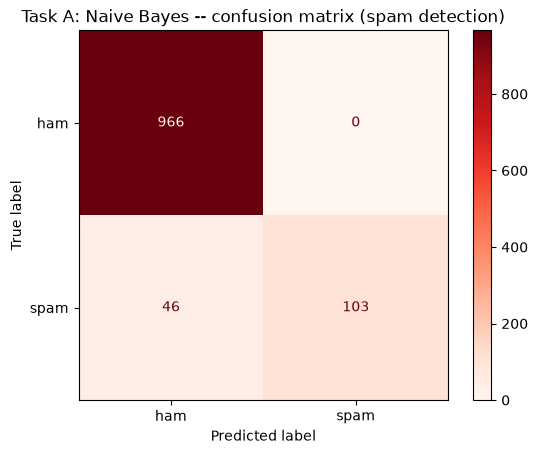

[[966   0]
 [ 46 103]]


In [6]:
# Task 5 -- train MultinomialNB, compute metrics, plot confusion matrix
nb_spam = MultinomialNB()
nb_spam.fit(X_train_vec, y_train)
nb_spam_pred = nb_spam.predict(X_test_vec)

nb_spam_metrics = {
    "accuracy": accuracy_score(y_test, nb_spam_pred),
    "precision": precision_score(y_test, nb_spam_pred),
    "recall": recall_score(y_test, nb_spam_pred),
    "f1": f1_score(y_test, nb_spam_pred),
}
print(pd.DataFrame([nb_spam_metrics], index=["Naive Bayes (Spam)"]).round(4))

cm = confusion_matrix(y_test, nb_spam_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"])
disp.plot(cmap="Reds", values_format="d")
plt.title("Task A: Naive Bayes -- confusion matrix (spam detection)")
plt.show()

print(cm)


**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9587 |
| Precision | 1.0000 |
| Recall | 0.6913 |
| F1-score | 0.8175 |

**Answer 6:**
A false positive here — a real message wrongly hidden as spam — is worse than a false negative. A false negative (spam reaching the inbox) is a minor annoyance the user deletes in a second; a false positive can mean missing a one-time password, a job offer, or a message from a family member, with no way to know it ever arrived unless the user manually checks the spam folder. I would therefore prioritize **precision** if tuning further, accepting some spam getting through in exchange for near-zero real messages being hidden.

Interestingly, this specific model already reflects that priority without any tuning: the confusion matrix shows **0 false positives** (every one of the 966 test ham messages was correctly left alone) and 46 false negatives, which is exactly why precision is a perfect 1.0 while recall (69.13%) is the weaker number. The model is already erring on the safe side — the remaining work would be closing the recall gap (catching more of the 46 missed spam messages) without giving up that 0-false-positive property.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [7]:
# Task 7 -- extract top spam words and top ham words from feature_log_prob_
feature_names = np.array(vectorizer.get_feature_names_out())
ham_idx = list(nb_spam.classes_).index(0)
spam_idx = list(nb_spam.classes_).index(1)

log_prob_diff = nb_spam.feature_log_prob_[spam_idx] - nb_spam.feature_log_prob_[ham_idx]

top_spam_idx = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_idx = np.argsort(log_prob_diff)[:15]

top_spam_words = pd.DataFrame({
    "word": feature_names[top_spam_idx],
    "log_prob_diff": log_prob_diff[top_spam_idx],
})
top_ham_words = pd.DataFrame({
    "word": feature_names[top_ham_idx],
    "log_prob_diff": log_prob_diff[top_ham_idx],
})

print("Top 15 words most associated with SPAM:")
print(top_spam_words.round(3).to_string(index=False))
print("\nTop 15 words most associated with HAM:")
print(top_ham_words.round(3).to_string(index=False))


Top 15 words most associated with SPAM:
      word  log_prob_diff
     claim          3.654
     prize          3.465
       www          3.128
        uk          3.015
      tone          2.995
       ppm          2.991
guaranteed          2.975
        cs          2.922
     nokia          2.886
     pobox          2.809
       txt          2.777
   service          2.724
   awarded          2.706
  ringtone          2.694
        co          2.668

Top 15 words most associated with HAM:
 word  log_prob_diff
   gt         -3.155
   lt         -3.144
   my         -3.088
   ok         -3.061
   ll         -3.019
later         -2.980
  lor         -2.928
 come         -2.817
 home         -2.804
  but         -2.786
   da         -2.749
   he         -2.730
sorry         -2.702
   me         -2.599
  how         -2.585


**Answer 7:**
Mostly yes, and one clear no. The top spam words — `claim`, `prize`, `www`, `tone`, `ppm`, `guaranteed`, `nokia`, `pobox`, `txt`, `awarded`, `ringtone` — read exactly like the ringtone-subscription and prize-scam SMS spam that was common when this UK dataset was collected (`ppm` = pence per minute, a premium-rate billing term; `nokia`/`ringtone`/`tone` point to ringtone-subscription scams). These match intuition well.

The ham list mostly makes sense too — `ok`, `later`, `come`, `home`, `sorry`, `how` are exactly the casual, conversational words you'd expect in personal texts, and `lor` reflects the Singlish influence in part of this dataset's messages. But `gt` and `lt`, the two *strongest* ham words, do **not** match intuition on their own — I checked, and they are an artifact of the raw data: 244 messages contain literal unescaped HTML entities like `&lt;#&gt;` and `&lt;URL&gt;`, which the dataset's creators used as placeholders for redacted numbers and links. My cleaning step strips everything except letters, so `&lt;#&gt;` turns into the words "lt" and "gt" — and because these redaction placeholders happen to appear overwhelmingly in personal (ham) messages, the model picked them up as strong ham signal. It is a real pattern in this exact dataset, but not a word a human would recognize as meaningfully "ham-like" — it is a cleaning artifact the model exploited anyway.

In [8]:
# Task 8 -- test your own messages
my_messages = [
    "URGENT! You have won a free ticket to Bahamas, call now to claim your prize!!!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "Congratulations, you have been selected for a $1000 Walmart gift card, click here now",
]

my_clean = [simple_clean(m) for m in my_messages]
my_vec = vectorizer.transform(my_clean)
my_pred = nb_spam.predict(my_vec)
my_proba = nb_spam.predict_proba(my_vec)

for msg, pred, proba in zip(my_messages, my_pred, my_proba):
    label = "SPAM" if pred == 1 else "HAM"
    print(f"[{label}] (P(spam)={proba[1]:.3f})  {msg}")


[SPAM] (P(spam)=0.885)  URGENT! You have won a free ticket to Bahamas, call now to claim your prize!!!
[HAM] (P(spam)=0.002)  Hey, are we still meeting for lunch tomorrow at 1pm?
[HAM] (P(spam)=0.323)  Congratulations, you have been selected for a $1000 Walmart gift card, click here now


**Answer 8:**
Two out of three matched expectations, and the third is a genuinely useful miss. The obviously spam-like message ("URGENT! ... free ticket ... call now to claim your prize") was correctly flagged SPAM with high confidence (P(spam)=0.885), and the plain lunch-plans message was correctly HAM with very low spam probability (P(spam)=0.002).

The Walmart gift-card message, though, was predicted HAM (P(spam)=0.323) even though I intended it as an obvious spam example. This is not a random error — it reflects Part 4's word list. This training data is dominated by UK ringtone/prize-scam vocabulary from around 2011 (`nokia`, `ppm`, `txt`, `ringtone`); it never saw words like "walmart", "gift", or "card" used as spam, so the model has no learned signal for this more modern, US-style scam pattern. It is a concrete illustration of train/test distribution mismatch: a spam filter trained on one era and style of spam text does not automatically generalize to a different style it has never seen, even when a human would recognize both as spam instantly.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/aftabgaming/notebookd18e0b1c04

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [9]:
# Task 11 -- clean and vectorize the sentiment data (your own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # links: no word-level sentiment signal
    text = re.sub(r"@\w+", " ", text)                 # @mentions: airline handles/usernames, not sentiment words
    text = re.sub(r"[^a-z\s]", " ", text)              # strip punctuation/numbers; hashtag WORDS survive, only the '#' is stripped
    text = re.sub(r"\s+", " ", text).strip()
    return text

tweets_df["clean_text"] = tweets_df["text"].apply(clean_tweet)
tweets_df["sentiment_bin"] = tweets_df["airline_sentiment"].map({"negative": 0, "positive": 1})

Xt_train_text, Xt_test_text, yt_train, yt_test = train_test_split(
    tweets_df["clean_text"], tweets_df["sentiment_bin"],
    test_size=0.20, random_state=42, stratify=tweets_df["sentiment_bin"]
)

tweet_vectorizer = TfidfVectorizer()
Xt_train_vec = tweet_vectorizer.fit_transform(Xt_train_text)
Xt_test_vec = tweet_vectorizer.transform(Xt_test_text)

print("Train tweets:", Xt_train_text.shape[0], "| Test tweets:", Xt_test_text.shape[0])
print("Vocabulary size (features):", len(tweet_vectorizer.get_feature_names_out()))
tweets_df[["text", "clean_text"]].head()


Train tweets: 9232 | Test tweets: 2309
Vocabulary size (features): 8747


,text,clean_text
0,@VirginAmerica plus you've added commercials t...,plus you ve added commercials to the experienc...
1,@VirginAmerica it's really aggressive to blast...,it s really aggressive to blast obnoxious ente...
2,@VirginAmerica and it's a really big bad thing...,and it s a really big bad thing about it
3,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
4,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...


**Answer 12:**
Tweets needed two cleaning steps beyond what the SMS messages needed: stripping URLs and stripping `@mentions`. SMS messages rarely contain either, but tweets are full of them — `@VirginAmerica`, `@united`, links to photos or booking pages — and these are structural Twitter artifacts (an airline handle, a random shortened URL) rather than words that carry sentiment, so leaving them in would only add noise and inflate the vocabulary with tokens that don't help classification. I kept hashtag *words* (only stripping the `#` symbol) since a hashtag like `#neveragain` still contains a real, sentiment-bearing word once the symbol is removed.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

                         accuracy  precision  recall      f1
Naive Bayes (Sentiment)     0.835        1.0  0.1945  0.3257


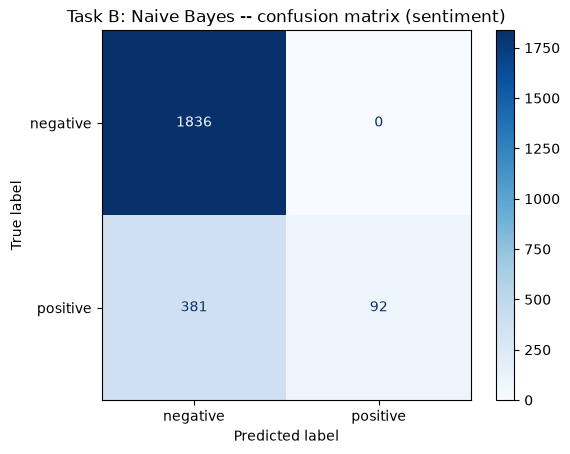

[[1836    0]
 [ 381   92]]


In [10]:
# Task 13 -- train MultinomialNB, compute metrics, plot confusion matrix
nb_sent = MultinomialNB()
nb_sent.fit(Xt_train_vec, yt_train)
nb_sent_pred = nb_sent.predict(Xt_test_vec)

nb_sent_metrics = {
    "accuracy": accuracy_score(yt_test, nb_sent_pred),
    "precision": precision_score(yt_test, nb_sent_pred),
    "recall": recall_score(yt_test, nb_sent_pred),
    "f1": f1_score(yt_test, nb_sent_pred),
}
print(pd.DataFrame([nb_sent_metrics], index=["Naive Bayes (Sentiment)"]).round(4))

cm = confusion_matrix(yt_test, nb_sent_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Task B: Naive Bayes -- confusion matrix (sentiment)")
plt.show()

print(cm)


**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8350 |
| Precision | 1.0000 |
| Recall | 0.1945 |
| F1-score | 0.3257 |

**Answer 14:**
Naive Bayes did dramatically worse on sentiment than on spam — F1 fell from 0.8175 (spam) to 0.3257 (sentiment), even though accuracy alone (83.5%) looks reasonable. The confusion matrix explains why: 0 false positives again, but this time 381 false negatives out of only 473 actual positive tweets in the test set — the model caught just 92 of them (recall 19.45%). With 79.53% of tweets negative, Naive Bayes leaned almost entirely on that class and on strong negative keywords, rather than genuinely learning what makes a tweet positive.

This connects directly to the independence assumption. Spam text is short and formulaic — words like "claim" or "prize" carry almost the same spam signal regardless of what surrounds them, so treating words as independent costs little. Tweets are the opposite: sentiment often depends on word combinations and context the independence assumption throws away — negation ("not good"), sarcasm ("thanks for losing my bag, great service"), and comparisons all change the meaning of individual words in ways Naive Bayes cannot represent, since it only ever asks "how often does this word appear in each class" one word at a time. The independence assumption is therefore far less reasonable for tweets than for spam SMS, and the class imbalance makes the resulting weakness (poor recall on the minority class) much more visible here than it was on the more balanced-error spam task.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/aftabgaming/notebook66b6b55baf

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9587 | 0.8350 |
| Precision | 1.0000 | 1.0000 |
| Recall | 0.6913 | 0.1945 |
| F1-score | 0.8175 | 0.3257 |

In [11]:
# Task 18 -- train Logistic Regression on Task A's vectorized features
logreg_spam = LogisticRegression(max_iter=1000, random_state=42)
logreg_spam.fit(X_train_vec, y_train)
logreg_spam_pred = logreg_spam.predict(X_test_vec)

logreg_spam_metrics = {
    "accuracy": accuracy_score(y_test, logreg_spam_pred),
    "precision": precision_score(y_test, logreg_spam_pred),
    "recall": recall_score(y_test, logreg_spam_pred),
    "f1": f1_score(y_test, logreg_spam_pred),
}
print(pd.DataFrame([nb_spam_metrics, logreg_spam_metrics], index=["Naive Bayes", "Logistic Regression"]).round(4))


                     accuracy  precision  recall      f1
Naive Bayes            0.9587     1.0000  0.6913  0.8175
Logistic Regression    0.9695     0.9915  0.7785  0.8722


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9587 | 0.9695 |
| Precision | 1.0000 | 0.9915 |
| Recall | 0.6913 | 0.7785 |
| F1-score | 0.8175 | 0.8722 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression wins on every metric except precision, where it gives up a negligible 0.0085 (still 99.15%) in exchange for a meaningfully higher recall (77.85% vs. 69.13%) — it catches 12 more of the 149 spam messages in the test set while missing almost none of the real ones. This does match what the independence assumption would predict: Naive Bayes treats every word's contribution to "spamminess" as separate and additive, while Logistic Regression learns weights that can offset and interact through gradient-based optimization rather than assuming each word's evidence is independent of the others. Since real spam messages combine multiple suspicious words in the same sentence, a model that isn't forced to treat them as independent has a genuine advantage, even on a dataset well-suited to Naive Bayes.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes suited the spam detection task far better than the sentiment task, and the metrics from Part 9's table make that gap impossible to miss — F1 of 0.8175 on spam versus just 0.3257 on sentiment, despite a respectable-looking 83.5% accuracy on the sentiment task. What surprised me most in Part 4 was that the two strongest "ham" words, `gt` and `lt`, were not real words at all: they turned out to be leftover fragments of unescaped HTML placeholders (`&lt;#&gt;`, `&lt;URL&gt;`) used to redact numbers and links in the original dataset, which my cleaning step accidentally turned into vocabulary. Against Logistic Regression, Naive Bayes was competitive but lost on every metric that matters here, most notably recall (69.13% vs. 77.85%), because Logistic Regression can weigh combinations of words together instead of scoring each one in isolation. The clearest limitation of the independence assumption I personally observed was in Part 7: on the imbalanced, context-dependent sentiment data, Naive Bayes achieved perfect precision but only 19.45% recall, essentially defaulting to the majority (negative) class rather than genuinely learning what distinguishes a positive tweet — a failure mode that spam's short, formulaic, keyword-driven text never exposed. Together these two tasks show Naive Bayes as a strong, fast baseline for problems where individual words are already highly diagnostic on their own, but a weaker choice once meaning depends on how words combine, exactly where every tabular classifier from Labs 3–6 was never tested at all, since none of them ever saw raw text.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/aftabgaming/notebookd18e0b1c04
- Task B: https://www.kaggle.com/code/aftabgaming/notebook66b6b55baf

---

## Submission Checklist

Before submitting, confirm you have:

- [x] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [x] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [x] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [x] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [x] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [x] Section 5 — Task A Kaggle Notebook published and linked
- [x] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [x] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [x] Section 8 — Task B Kaggle Notebook published and linked
- [x] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [x] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted